# 27 — Atomic-group rights hierarchy

Builds a binary right vector per atomic social group from the Archaic+Classical Greek corpus, applies asymmetric markedness on LESS rules, and renders the partial-order Hasse on top atomic groups.

In [2]:
from pathlib import Path
from itertools import product

import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

pd.set_option('display.max_colwidth', 220)
pd.set_option('display.max_rows', 200)

ROOT = Path('..').resolve()
RULES_PATH = ROOT / 'data/clean/final/rules_with_criteria.tsv'

In [3]:
AXES = [
    'c_sex',
    'c_age',
    'c_ownership_status',
    'c_ancestry',
    'c_residence',
    'c_wealth',
]

AXIS_VALUES = {
    'c_sex':              ['Male', 'Female'],
    'c_age':               ['Adult', 'Minor'],
    'c_ownership_status': ['Free', 'Enslaved'],
    'c_ancestry':         ['Native', 'Foreign'],
    'c_residence':        ['Resident', 'Non resident'],
    'c_wealth':           ['High', 'Low'],
}

PRIVILEGED_VALUE = {
    'c_sex':              'Male',
    'c_age':              'Adult',
    'c_ownership_status': 'Free',
    'c_ancestry':         'Native',
    'c_residence':        'Resident',
    'c_wealth':           'High',
}

MARKED_VALUE = {
    'c_sex':              'Female',
    'c_age':              'Minor',
    'c_ownership_status': 'Enslaved',
    'c_ancestry':         'Foreign',
    'c_residence':        'Non resident',
}

In [4]:
ORTHOGONAL_RESOURCES = [
    'Eligibility for public office',
    'Political power',
    'Right to a legal trial',
    'Right to vote in the Ekklesia',
    'Right to dispose / inherit property',
    'Right to retain property',
    'Right to public speech',
    'Right to marriage / dowry',
    'Protection from capital / corporal punishment',
]

RESOURCE_TO_BUCKET = {
    'Right to own land':                              'Right to retain property',
    'Right to retain own earnings':                   'Right to retain property',
    'Right to own property':                          'Right to retain property',
    'Right to retain property':                       'Right to retain property',
    'Right to dispose of property':                   'Right to dispose / inherit property',
    'Right to inherit property':                      'Right to dispose / inherit property',
    'Right to dispose / inherit property':            'Right to dispose / inherit property',
    'Right to address the assembly':                  'Right to public speech',
    'Right to speak first in assembly':               'Right to public speech',
    'Right to free speech':                           'Right to public speech',
    'Right to public speech':                         'Right to public speech',
    'Right to remuneration for office':               'Eligibility for public office',
    'Eligibility for public office':                  'Eligibility for public office',
    'Right to a dowry':                               'Right to marriage / dowry',
    'Right to marry':                                 'Right to marriage / dowry',
    'Right to marriage / dowry':                      'Right to marriage / dowry',
    'Right to professional judgement':                'Right to a legal trial',
    'Right to valid professional opinion':            'Right to a legal trial',
    'Right to a legal trial':                         'Right to a legal trial',
    'Protection from capital punishment':             'Protection from capital / corporal punishment',
    'Protection from corporal punishment':            'Protection from capital / corporal punishment',
    'Protection from capital / corporal punishment':  'Protection from capital / corporal punishment',
    'Right to vote in the Ekklesia':                  'Right to vote in the Ekklesia',
    'Political power':                                'Political power',
}

In [5]:
AXIS_BINARY_FLIP = {
    'c_sex':              {'Male':     'Female',       'Female':       'Male'},
    'c_age':              {'Adult':    'Minor',        'Minor':        'Adult'},
    'c_ownership_status': {'Free':     'Enslaved',     'Enslaved':     'Free'},
    'c_ancestry':         {'Native':   'Foreign',      'Foreign':      'Native'},
    'c_residence':        {'Resident': 'Non resident', 'Non resident': 'Resident'},
}

GROUP_LABEL_TO_AXIS = {
    'Women':              'c_sex',
    'Wives':              'c_sex',
    'Daughters':          'c_sex',
    'Mothers':            'c_sex',
    'Female citizens':    'c_sex',
    'Female slaves':      'c_sex',
    'Men':                'c_sex',
    'Husbands':           'c_sex',
    'Sons':               'c_sex',
    'Fathers':            'c_sex',
    'Male citizens':      'c_sex',
    'Slaves':             'c_ownership_status',
    'Slave':              'c_ownership_status',
    'Free men':           'c_ownership_status',
    'Free persons':       'c_ownership_status',
    'Freedmen':           'c_ownership_status',
    'Minors':             'c_age',
    'Children':           'c_age',
    'Orphans':            'c_age',
    'Adults':             'c_age',
    'Elders':             'c_age',
    'Foreigners':         'c_ancestry',
    'Aliens':             'c_ancestry',
    'Metics':             'c_ancestry',
    'Resident aliens':    'c_ancestry',
    'Free non-citizens':  'c_ancestry',
    'Natives':            'c_ancestry',
    'Greeks':             'c_ancestry',
    'Non-residents':      'c_residence',
    'Residents':          'c_residence',
}

In [6]:
def normalize_axis_token(value):
    if pd.isna(value):
        return '*'
    text = str(value)
    if text in ('any', 'unspecified'):
        return '*'
    return text.replace('_', ' ').capitalize()

rules_raw = pd.read_csv(RULES_PATH, sep='\t')
rules_raw['rule_criterion_signature'] = rules_raw.apply(
    lambda row: '/'.join(normalize_axis_token(row[axis]) for axis in AXES), axis=1
)
rules_raw['resource_bucket'] = rules_raw['resource_meta'].map(RESOURCE_TO_BUCKET)

print('rules_raw.shape =', rules_raw.shape)
rules_raw[['rule_id', 'group', 'directionality', 'resource_meta', 'resource_bucket', 'rule_polity', 'rule_criterion_signature']].head()

rules_raw.shape = (1011, 49)


,rule_id,group,directionality,resource_meta,resource_bucket,rule_polity,rule_criterion_signature
0,tlg0007.tlg118.perseus-eng3::0,Greeks,LESS,Political power,Political power,Roman Empire,*/*/*/Foreign/*/*
1,tlg0007.tlg118.perseus-eng3::1,Citizens of Greek city-states,MORE,Political power,Political power,Roman Empire,Male/Adult/Free/Native/Resident/*
2,tlg0007.tlg118.perseus-eng3::2,Nobles,MORE,Eligibility for public office,Eligibility for public office,Roman Empire,*/Adult/Free/Native/*/High
3,tlg0007.tlg118.perseus-eng3::3,Citizens,MORE,Right to vote in the Ekklesia,Right to vote in the Ekklesia,Roman Empire,Male/Adult/Free/Mixed/*/*
4,tlg0007.tlg118.perseus-eng3::5,Citizens,LESS,Political power,Political power,Roman Empire,Male/Adult/Free/Mixed/*/*


In [7]:
archaic_classical_polities = sorted({
    polity for polity in rules_raw['rule_polity'].dropna().unique()
    if 'Archaic' in polity or 'Classical' in polity
})

rules_in_scope = rules_raw[
    rules_raw['rule_polity'].isin(archaic_classical_polities)
    & (rules_raw['requires_rights_definition'] != True)
    & (rules_raw['tautology'] != 1)
    & rules_raw['resource_bucket'].isin(ORTHOGONAL_RESOURCES)
    & rules_raw['directionality'].isin(['MORE', 'LESS'])
].copy()

print('rules_in_scope.shape =', rules_in_scope.shape)
print('  MORE =', (rules_in_scope['directionality'] == 'MORE').sum())
print('  LESS =', (rules_in_scope['directionality'] == 'LESS').sum())
rules_in_scope[['rule_id','group','directionality','resource_bucket','rule_polity','rule_criterion_signature']].head()

rules_in_scope.shape = (435, 49)
  MORE = 275
  LESS = 160


,rule_id,group,directionality,resource_bucket,rule_polity,rule_criterion_signature
6,tlg0007.tlg119.perseus-eng3::2,Nobles,MORE,Political power,Classical Sparta,Male/Adult/Free/Native/Resident/High
7,tlg0014.tlg059.perseus-eng2::0,Citizens,MORE,Political power,Classical Athens,Male/Adult/Free/Native/Resident/*
10,tlg0014.tlg059.perseus-eng2::3,Aliens,LESS,Right to marriage / dowry,Classical Athens,*/*/Free/Foreign/Resident/*
13,tlg0014.tlg059.perseus-eng2::7,Wives,MORE,Right to marriage / dowry,Classical Athens,Female/Adult/Free/*/Resident/*
16,tlg0014.tlg059.perseus-eng2::12,Slaves,LESS,Protection from capital / corporal punishment,Classical Athens,*/*/Enslaved/*/Resident/Low


### Atomic groups

Cartesian product of the six binary axes = 64 fully-specified groups. Each gets a stable `G1..G64` id from a 6-bit *privilege* encoding: 0 = privileged value on that axis, 1 = marked value; read as an integer ascending. So **G1** = all-zero = `Male/Adult/Free/Native/Resident/High`; **G64** = all-one = `Female/Minor/Enslaved/Foreign/Non resident/Low`.

In [21]:
atomic_groups_64 = ['/'.join(combo) for combo in product(*[AXIS_VALUES[ax] for ax in AXES])]

def encode_privilege_bits(criterion_signature):
    bits = 0
    for axis_index, (axis, value) in enumerate(zip(AXES, criterion_signature.split('/'))):
        if value != PRIVILEGED_VALUE[axis]:
            bits |= 1 << (len(AXES) - 1 - axis_index)
    return bits

atomic_groups_ranked = sorted(atomic_groups_64, key=encode_privilege_bits)
GROUP_TO_GID = {group: f'G{i+1}' for i, group in enumerate(atomic_groups_ranked)}

print('len(atomic_groups_64) =', len(atomic_groups_64))
pd.DataFrame({
    'gid':       [GROUP_TO_GID[g] for g in atomic_groups_ranked],
    'criterion': atomic_groups_ranked,
}).head(10)


len(atomic_groups_64) = 64


,gid,criterion
0,G1,Male/Adult/Free/Native/Resident/High
1,G2,Male/Adult/Free/Native/Resident/Low
2,G3,Male/Adult/Free/Native/Non resident/High
3,G4,Male/Adult/Free/Native/Non resident/Low
4,G5,Male/Adult/Free/Foreign/Resident/High
5,G6,Male/Adult/Free/Foreign/Resident/Low
6,G7,Male/Adult/Free/Foreign/Non resident/High
7,G8,Male/Adult/Free/Foreign/Non resident/Low
8,G9,Male/Adult/Enslaved/Native/Resident/High
9,G10,Male/Adult/Enslaved/Native/Resident/Low


In [24]:
def specific_emic_name(criterion_signature):
    sex, age, ownership, ancestry, residence, wealth = criterion_signature.split('/')

    if ownership == 'Enslaved':
        core = 'slave girls' if (sex == 'Female' and age == 'Minor') else \
               'slave boys'  if (sex == 'Male'   and age == 'Minor') else \
               'slave women' if  sex == 'Female' else 'slave men'
    elif age == 'Minor':
        core = ('girls' if ancestry == 'Native' else 'foreign girls') if sex == 'Female' else \
               ('boys'  if ancestry == 'Native' else 'foreign boys')
    elif sex == 'Female':
        core = 'wives' if ancestry == 'Native' else 'foreign women'
    else:
        core = 'citizens' if ancestry == 'Native' else 'foreign men'

    modifiers = []
    modifiers.append({'High': 'Wealthy', 'Low': 'Poor'}[wealth])
    if ancestry == 'Foreign' and ownership == 'Enslaved':
        modifiers.append('foreign')
    if residence == 'Non resident':
        modifiers.append('non-resident')

    return ' '.join(modifiers + [core])

atomic_groups_table = pd.DataFrame({
    'gid':       [GROUP_TO_GID[g] for g in atomic_groups_ranked],
    'criterion': atomic_groups_ranked,
    'emic':      [specific_emic_name(g) for g in atomic_groups_ranked],
})
print('atomic_groups_table.shape =', atomic_groups_table.shape)
atomic_groups_table.head(10)


atomic_groups_table.shape = (64, 3)


,gid,criterion,emic
0,G1,Male/Adult/Free/Native/Resident/High,Wealthy citizens
1,G2,Male/Adult/Free/Native/Resident/Low,Poor citizens
2,G3,Male/Adult/Free/Native/Non resident/High,Wealthy non-resident citizens
3,G4,Male/Adult/Free/Native/Non resident/Low,Poor non-resident citizens
4,G5,Male/Adult/Free/Foreign/Resident/High,Wealthy foreign men
5,G6,Male/Adult/Free/Foreign/Resident/Low,Poor foreign men
6,G7,Male/Adult/Free/Foreign/Non resident/High,Wealthy non-resident foreign men
7,G8,Male/Adult/Free/Foreign/Non resident/Low,Poor non-resident foreign men
8,G9,Male/Adult/Enslaved/Native/Resident/High,Wealthy slave men
9,G10,Male/Adult/Enslaved/Native/Resident/Low,Poor slave men


In [25]:
def atomic_refines_rule(atomic_signature, rule_signature):
    for atomic_value, rule_value in zip(atomic_signature.split('/'), rule_signature.split('/')):
        if rule_value == '*':
            continue
        if rule_value == 'Middle':
            return False
        if atomic_value != rule_value:
            return False
    return True

def salient_axis_for_less_rule(group_label, rule_signature):
    if isinstance(group_label, str) and group_label in GROUP_LABEL_TO_AXIS:
        return GROUP_LABEL_TO_AXIS[group_label]
    rule_tokens = rule_signature.split('/')
    pinned = [
        AXES[i] for i in range(len(AXES))
        if AXES[i] in AXIS_BINARY_FLIP and rule_tokens[i] in AXIS_BINARY_FLIP[AXES[i]]
    ]
    return pinned[0] if len(pinned) == 1 else None

### Evidence tallies

For every (atomic group, resource bucket) we count three kinds of evidence:

- **`more_evidence`** — MORE rules whose criterion signature is *refined* by the atomic group (lifting downward).
- **`less_evidence`** — LESS rules with a salient binary axis pinned to value `v`; every atomic group with that same axis-value gets `+1` (broad denial along the axis).
- **`complement_evidence`** — asymmetric markedness: only when the LESS rule is on the **marked** value of the axis (Female, Minor, Enslaved, Foreign, Non resident) does the unmarked complement get `+1`.

*Slaves cannot X* ⇒ *Free can X* fires here; *Free cannot X* ⇒ *Slaves can X* does **not**.

In [26]:
more_evidence = np.zeros((len(atomic_groups_64), len(ORTHOGONAL_RESOURCES)), dtype=int)
less_evidence = np.zeros_like(more_evidence)
complement_evidence = np.zeros_like(more_evidence)

group_index   = {group: idx for idx, group in enumerate(atomic_groups_64)}
resource_index = {res: idx for idx, res in enumerate(ORTHOGONAL_RESOURCES)}

n_less_dropped = 0

for _, rule in rules_in_scope.iterrows():
    rule_signature = rule['rule_criterion_signature']
    resource_col   = resource_index[rule['resource_bucket']]
    if rule['directionality'] == 'MORE':
        for atomic in atomic_groups_64:
            if atomic_refines_rule(atomic, rule_signature):
                more_evidence[group_index[atomic], resource_col] += 1
        continue
    axis = salient_axis_for_less_rule(rule.get('group',''), rule_signature)
    if axis is None:
        n_less_dropped += 1
        continue
    axis_idx = AXES.index(axis)
    rule_axis_value = rule_signature.split('/')[axis_idx]
    if rule_axis_value not in AXIS_BINARY_FLIP[axis]:
        n_less_dropped += 1
        continue
    for atomic in atomic_groups_64:
        if atomic.split('/')[axis_idx] == rule_axis_value:
            less_evidence[group_index[atomic], resource_col] += 1
    if rule_axis_value == MARKED_VALUE.get(axis):
        complement_value = AXIS_BINARY_FLIP[axis][rule_axis_value]
        for atomic in atomic_groups_64:
            if atomic.split('/')[axis_idx] == complement_value:
                complement_evidence[group_index[atomic], resource_col] += 1

print('more_evidence.shape        =', more_evidence.shape, '  total signals =', int(more_evidence.sum()))
print('less_evidence.shape        =', less_evidence.shape, '  total signals =', int(less_evidence.sum()))
print('complement_evidence.shape  =', complement_evidence.shape, '  total signals =', int(complement_evidence.sum()))
print('LESS rules dropped (no salient axis) =', n_less_dropped)

more_evidence.shape        = (64, 9)   total signals = 1517
less_evidence.shape        = (64, 9)   total signals = 2304
complement_evidence.shape  = (64, 9)   total signals = 2144
LESS rules dropped (no salient axis) = 88


### Bit decision (frequency rule + complement fallback)

For each (atomic group, resource), the bit is `1` iff one of:

- **Case 1**: `more_evidence > less_evidence` — direct positive outweighs broad denial.
- **Case 2**: `less_evidence == 0` *and* `complement_evidence > 0` — no broad denial at all, asymmetric markedness infers the right.

Otherwise the bit is `0`. The frequency principle is encoded as Case 1: many LESS rules on a group's axis dominate stray MORE rules and the right is denied.

In [27]:
case_direct_wins = more_evidence > less_evidence
case_complement_fallback = (less_evidence == 0) & (complement_evidence > 0)
right_vectors = (case_direct_wins | case_complement_fallback).astype(int)

right_vectors_table = pd.DataFrame({
    'gid':       [GROUP_TO_GID[g] for g in atomic_groups_64],
    'criterion': atomic_groups_64,
    'emic':      [specific_emic_name(g) for g in atomic_groups_64],
    'rights':    [''.join(str(b) for b in right_vectors[i]) for i in range(len(atomic_groups_64))],
    'n_rights':  right_vectors.sum(axis=1),
}).sort_values('n_rights', ascending=False).reset_index(drop=True)

print('right_vectors.shape =', right_vectors.shape)
right_vectors_table.head(12)

right_vectors.shape = (64, 9)


,gid,criterion,emic,rights,n_rights
0,G1,Male/Adult/Free/Native/Resident/High,Wealthy citizens,111111111,9
1,G18,Male/Minor/Free/Native/Resident/Low,Poor boys,111111111,9
2,G49,Female/Minor/Free/Native/Resident/High,Wealthy girls,111111111,9
3,G2,Male/Adult/Free/Native/Resident/Low,Poor citizens,111111111,9
4,G33,Female/Adult/Free/Native/Resident/High,Wealthy wives,111111111,9
5,G17,Male/Minor/Free/Native/Resident/High,Wealthy boys,111111011,8
6,G50,Female/Minor/Free/Native/Resident/Low,Poor girls,111101111,8
7,G34,Female/Adult/Free/Native/Resident/Low,Poor wives,111101111,8
8,G6,Male/Adult/Free/Foreign/Resident/Low,Poor foreign men,111110101,7
9,G37,Female/Adult/Free/Foreign/Resident/High,Wealthy foreign women,101101111,7


### Per-axis-value rights-effect

For each axis-value `v`, the mean rights count over the 32 atomic groups carrying `v` on that axis. High mean = the value is *rights-conferring*; low mean = *rights-restricting*.

In [28]:
rights_per_atomic_group = right_vectors.sum(axis=1)

axis_value_effect = pd.DataFrame([
    {
        'axis':        axis,
        'value':       value,
        'mean_rights': float(np.mean([
            rights_per_atomic_group[group_index[g]]
            for g in atomic_groups_64
            if g.split('/')[AXES.index(axis)] == value
        ])),
    }
    for axis in AXES for value in AXIS_VALUES[axis]
])

print('axis_value_effect.shape =', axis_value_effect.shape)
axis_value_effect

axis_value_effect.shape = (12, 3)


,axis,value,mean_rights
0,c_sex,Male,3.09375
1,c_sex,Female,2.90625
2,c_age,Adult,3.43750
3,c_age,Minor,2.56250
4,c_ownership_status,Free,4.90625
5,c_ownership_status,Enslaved,1.09375
6,c_ancestry,Native,4.06250
7,c_ancestry,Foreign,1.93750
8,c_residence,Resident,4.18750
9,c_residence,Non resident,1.81250


### Privilege score

Sum of the six per-axis-value mean rights for each atomic group. Continuous index used in §Hasse as the horizontal tiebreaker within a rights-count band.

In [29]:
axis_value_to_mean_rights = dict(zip(
    zip(axis_value_effect['axis'], axis_value_effect['value']),
    axis_value_effect['mean_rights'],
))

def privilege_score(criterion_signature):
    return sum(
        axis_value_to_mean_rights[(axis, value)]
        for axis, value in zip(AXES, criterion_signature.split('/'))
    )

privilege_scores_table = pd.DataFrame({
    'gid':       [GROUP_TO_GID[g] for g in atomic_groups_64],
    'criterion': atomic_groups_64,
    'emic':      [specific_emic_name(g) for g in atomic_groups_64],
    'n_rights':  [int(rights_per_atomic_group[group_index[g]]) for g in atomic_groups_64],
    'score':     [round(privilege_score(g), 2) for g in atomic_groups_64],
}).sort_values('score', ascending=False).reset_index(drop=True)

print('privilege_scores_table.shape =', privilege_scores_table.shape)
privilege_scores_table.head(12)

privilege_scores_table.shape = (64, 5)


,gid,criterion,emic,n_rights,score
0,G1,Male/Adult/Free/Native/Resident/High,Wealthy citizens,9,22.69
1,G2,Male/Adult/Free/Native/Resident/Low,Poor citizens,9,22.69
2,G34,Female/Adult/Free/Native/Resident/Low,Poor wives,8,22.50
3,G33,Female/Adult/Free/Native/Resident/High,Wealthy wives,9,22.50
4,G17,Male/Minor/Free/Native/Resident/High,Wealthy boys,8,21.81
5,G18,Male/Minor/Free/Native/Resident/Low,Poor boys,9,21.81
6,G50,Female/Minor/Free/Native/Resident/Low,Poor girls,8,21.62
7,G49,Female/Minor/Free/Native/Resident/High,Wealthy girls,9,21.62
8,G5,Male/Adult/Free/Foreign/Resident/High,Wealthy foreign men,6,20.56
9,G6,Male/Adult/Free/Foreign/Resident/Low,Poor foreign men,7,20.56


In [30]:
N_TOP_TO_SHOW = 6
N_BOTTOM_TO_SHOW = 6

corpus_observed_atomic_groups = set(atomic_groups_64) & set(rules_in_scope['rule_criterion_signature'])
atomic_by_score_descending = sorted(atomic_groups_64, key=lambda g: -privilege_score(g))

shown_atomic_groups = sorted(
    set(atomic_by_score_descending[:N_TOP_TO_SHOW])
    | set(atomic_by_score_descending[-N_BOTTOM_TO_SHOW:])
    | corpus_observed_atomic_groups,
    key=lambda g: -privilege_score(g),
)

print('len(shown_atomic_groups)        =', len(shown_atomic_groups))
print('corpus_observed_atomic_groups   =', len(corpus_observed_atomic_groups))
pd.DataFrame({
    'gid':       [GROUP_TO_GID[g] for g in shown_atomic_groups],
    'emic':      [specific_emic_name(g) for g in shown_atomic_groups],
    'n_rights':  [int(rights_per_atomic_group[group_index[g]]) for g in shown_atomic_groups],
    'observed':  [g in corpus_observed_atomic_groups for g in shown_atomic_groups],
})

len(shown_atomic_groups)        = 13
corpus_observed_atomic_groups   = 4


,gid,emic,n_rights,observed
0,G2,Poor citizens,9,True
1,G1,Wealthy citizens,9,True
2,G33,Wealthy wives,9,True
3,G34,Poor wives,8,False
4,G17,Wealthy boys,8,False
5,G18,Poor boys,9,False
6,G14,Poor foreign slave men,1,True
7,G47,Wealthy foreign non-resident slave women,0,False
8,G48,Poor foreign non-resident slave women,0,False
9,G31,Wealthy foreign non-resident slave boys,0,False


### Partial order on the binary right vectors

For two atomic groups *A* and *B*, declare `A ⪰ B` iff every right held by *B* is also held by *A*, i.e. `rights(A) ⊇ rights(B)`. Strict containment `rights(A) ⊋ rights(B)` puts *A above B* in the partial order; equal sets are incomparable peers; otherwise (sets share no inclusion direction) the two are also incomparable.

**Steps**

1. Compute the rights-bit-set per atomic group.
2. Restrict to the *shown* set (top + bottom + corpus-observed).
3. Build `hasse_full`: a directed edge `A → B` whenever `rights(B) ⊊ rights(A)` strictly.
4. Take the **transitive reduction** (`hasse_covering = nx.transitive_reduction(hasse_full)`): keep only the *covering relations* — direct dominance steps with no intermediate cell between source and target. This is what makes the diagram readable; without it every transitive chain would be a separate arrow.
5. Carry the node attributes (`n_rights`, `score`, `emic`, `gid`, `observed`) onto the reduced graph for rendering.

In [16]:
atomic_to_rights_set = {
    g: frozenset(np.where(right_vectors[group_index[g]] == 1)[0])
    for g in atomic_groups_64
}

hasse_full = nx.DiGraph()
for atomic in shown_atomic_groups:
    hasse_full.add_node(
        atomic,
        n_rights=int(rights_per_atomic_group[group_index[atomic]]),
        score=privilege_score(atomic),
        emic=specific_emic_name(atomic),
        gid=GROUP_TO_GID[atomic],
        observed=(atomic in corpus_observed_atomic_groups),
    )
for a in shown_atomic_groups:
    for b in shown_atomic_groups:
        if a == b:
            continue
        if atomic_to_rights_set[b] < atomic_to_rights_set[a]:
            hasse_full.add_edge(a, b)

hasse_covering = nx.transitive_reduction(hasse_full)
for node, data in hasse_full.nodes(data=True):
    if node in hasse_covering.nodes:
        hasse_covering.nodes[node].update(data)

print('hasse_full.number_of_nodes()    =', hasse_full.number_of_nodes())
print('hasse_full.number_of_edges()    =', hasse_full.number_of_edges())
print('hasse_covering.number_of_edges() =', hasse_covering.number_of_edges())
pd.DataFrame([
    {'source': hasse_covering.nodes[u]['gid'],
     'target': hasse_covering.nodes[v]['gid']}
    for u, v in hasse_covering.edges()
]).head(10)

hasse_full.number_of_nodes()    = 13
hasse_full.number_of_edges()    = 55
hasse_covering.number_of_edges() = 21


,source,target
0,G2,G17
1,G2,G34
2,G1,G17
3,G1,G34
4,G33,G17
5,G33,G34
6,G34,G31
7,G34,G48
8,G34,G64
9,G34,G47


### Layout

Two stages: **vertical** = number of rights held (one band per distinct rights count, evenly spaced by `Y_BAND_SPACING`). **Horizontal within a band** = privilege score, highest leftward — the criterion-level signal breaks ties when two atomic groups hold the same bit count.

In [17]:
Y_BAND_SPACING = 3.4
X_BAND_PADDING = 3.5

nodes_by_n_rights = {}
for atomic in hasse_covering.nodes:
    nodes_by_n_rights.setdefault(hasse_covering.nodes[atomic]['n_rights'], []).append(atomic)

rights_level_to_y_rank = {n: i for i, n in enumerate(sorted(nodes_by_n_rights.keys()))}
max_nodes_per_band = max(len(v) for v in nodes_by_n_rights.values())

node_positions = {}
for n_rights, atomic_in_band in nodes_by_n_rights.items():
    atomic_in_band.sort(key=lambda g: -hasse_covering.nodes[g]['score'])
    n = len(atomic_in_band)
    for i, atomic in enumerate(atomic_in_band):
        node_positions[atomic] = (
            (i - (n - 1) / 2) * X_BAND_PADDING * (max_nodes_per_band / max(n, 1)),
            rights_level_to_y_rank[n_rights] * Y_BAND_SPACING,
        )

node_positions_table = pd.DataFrame([
    {'gid':      hasse_covering.nodes[atomic]['gid'],
     'emic':     hasse_covering.nodes[atomic]['emic'],
     'n_rights': hasse_covering.nodes[atomic]['n_rights'],
     'x':        round(node_positions[atomic][0], 2),
     'y':        round(node_positions[atomic][1], 2)}
    for atomic in hasse_covering.nodes
])
print('node_positions_table.shape =', node_positions_table.shape)
node_positions_table

node_positions_table.shape = (13, 5)


,gid,emic,n_rights,x,y
0,G2,Poor citizens,9,-7.88,10.2
1,G1,Wealthy citizens,9,-2.62,10.2
2,G33,Wealthy wives,9,2.62,10.2
3,G34,Poor wives,8,-5.25,6.8
4,G17,Wealthy boys,8,5.25,6.8
5,G18,Poor boys,9,7.88,10.2
6,G14,Poor foreign slave men,1,0.00,3.4
7,G47,Wealthy foreign non-resident slave women,0,-8.75,0.0
8,G48,Poor foreign non-resident slave women,0,-5.25,0.0
9,G31,Wealthy foreign non-resident slave boys,0,-1.75,0.0


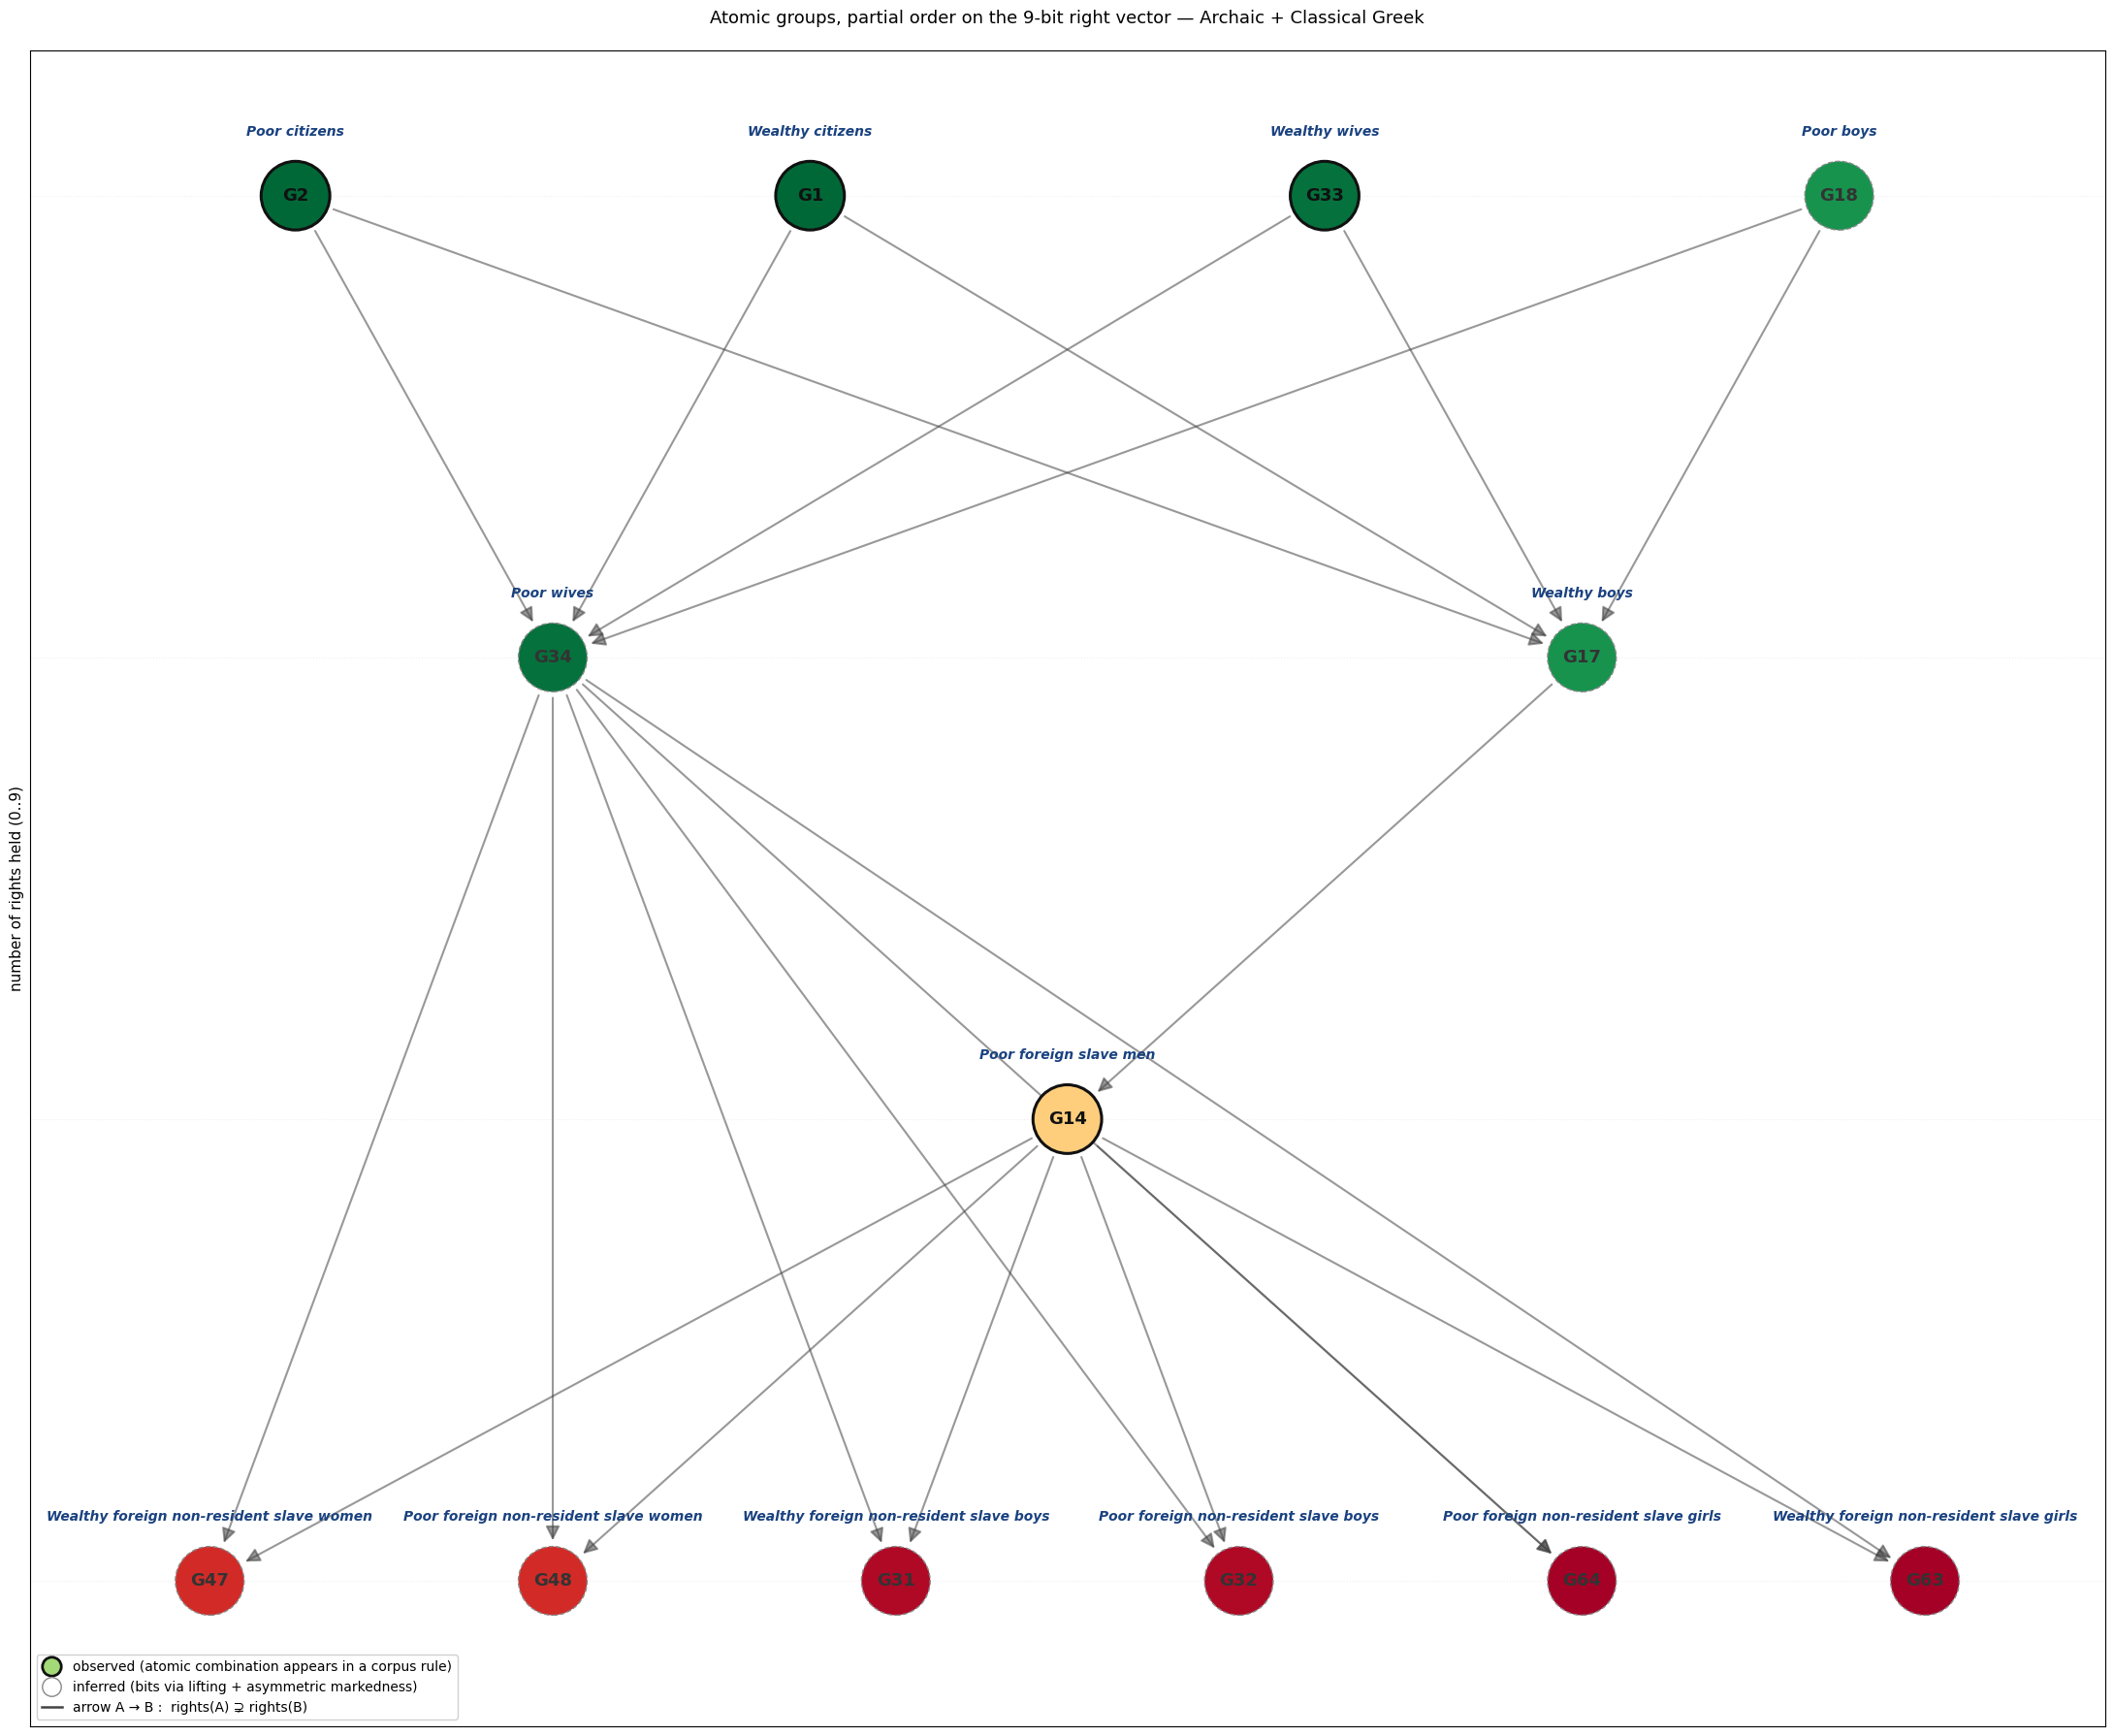

In [18]:
from matplotlib.lines import Line2D

fig, ax = plt.subplots(figsize=(22, 18))

nx.draw_networkx_edges(
    hasse_covering, node_positions, ax=ax,
    arrows=True, arrowstyle='-|>', arrowsize=22,
    width=1.5, alpha=0.55, edge_color='#444',
    connectionstyle='arc3,rad=0.0',
    min_target_margin=30, min_source_margin=30,
    node_size=2600,
)

observed_atomic_nodes = [g for g in hasse_covering.nodes if hasse_covering.nodes[g]['observed']]
inferred_atomic_nodes = [g for g in hasse_covering.nodes if not hasse_covering.nodes[g]['observed']]
score_min = min(hasse_covering.nodes[g]['score'] for g in hasse_covering.nodes)
score_max = max(hasse_covering.nodes[g]['score'] for g in hasse_covering.nodes)

if observed_atomic_nodes:
    nx.draw_networkx_nodes(
        hasse_covering, node_positions, ax=ax, nodelist=observed_atomic_nodes,
        node_size=2600,
        node_color=[hasse_covering.nodes[g]['score'] for g in observed_atomic_nodes],
        cmap='RdYlGn', vmin=score_min, vmax=score_max,
        edgecolors='#111', linewidths=2.2,
    )
if inferred_atomic_nodes:
    inferred_artist = nx.draw_networkx_nodes(
        hasse_covering, node_positions, ax=ax, nodelist=inferred_atomic_nodes,
        node_size=2600,
        node_color=[hasse_covering.nodes[g]['score'] for g in inferred_atomic_nodes],
        cmap='RdYlGn', vmin=score_min, vmax=score_max,
        edgecolors='#888', linewidths=1.0,
    )
    inferred_artist.set_linestyle('--')

for atomic in hasse_covering.nodes:
    x, y = node_positions[atomic]
    ax.text(x, y + 0.42, hasse_covering.nodes[atomic]['emic'],
            ha='center', va='bottom', fontsize=10, fontweight='bold',
            style='italic', color='#1a4280')
    ax.text(x, y, hasse_covering.nodes[atomic]['gid'],
            ha='center', va='center', fontsize=13, fontweight='bold',
            color='#111' if hasse_covering.nodes[atomic]['observed'] else '#333')

ax.set_title('Atomic groups, partial order on the 9-bit right vector — Archaic + Classical Greek',
             fontsize=13, pad=20)
ax.set_ylabel('number of rights held (0..9)', fontsize=11)
rights_levels_sorted = sorted(rights_level_to_y_rank.keys())
ax.set_yticks([rights_level_to_y_rank[n] * Y_BAND_SPACING for n in rights_levels_sorted])
ax.set_yticklabels([str(n) for n in rights_levels_sorted])
ax.set_xticks([])
ax.legend(handles=[
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#a3d977',
           markeredgecolor='#111', markeredgewidth=2.0, markersize=14,
           label='observed (atomic combination appears in a corpus rule)'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#ffffff',
           markeredgecolor='#888', markeredgewidth=1.0, markersize=14,
           label='inferred (bits via lifting + asymmetric markedness)'),
    Line2D([0], [0], color='#444', lw=1.8,
           label='arrow A → B :  rights(A) ⊋ rights(B)'),
], loc='lower left', fontsize=10, framealpha=0.92, handlelength=1.5)
ax.grid(axis='y', alpha=0.20, linestyle=':')
ax.set_facecolor('white')
plt.tight_layout()
plt.show()